# Do rising jobless claims warn you before the market falls? 📰
### The 'most important weekly number' as a stock-market crystal ball, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Early_warning%3F: Not_supported](https://img.shields.io/badge/Early_warning%3F-Not_supported-8b949e?style=flat-square)

Every Thursday morning the U.S. reports how many people just filed for unemployment. When that number — smoothed into a **4-week average** — starts climbing, the folklore says the economy is rolling over and a **stock-market downturn is coming**. Claims *lead*, the story goes, so a claims uptick is your early-warning to get defensive.

It's a great story. It's also testable. This notebook asks three blunt questions: when claims rise, does the market really do worse? Does the claims uptick actually come **first** (that's the whole pitch)? And if you *sold* every time claims rose, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the lead/lag cross-correlation and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The live FRED feed is blocked in this environment, so we use a **frozen snapshot** of the official 4-week-average claims series (the settled numbers, not the real-time prints) — public and faithful, including the giant COVID-2020 spike. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from jobless_claims_momentum import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| claims+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-31', 'end': '2026-06-30', 'months': 402, 'years': 33.4, 'h1': (1, 174, 0.69, 1.15, 0.95, 36, 35, -0.63, 0.201), 'h3': (3, 172, 2.3, 3.3, 2.87, 31, 28, -0.76, 0.149), 'h6': (6, 171, 4.91, 6.49, 5.8, 29, 24, -0.81, 0.137), 'h12': (12, 168, 10.38, 13.29, 12.04, 24, 18, -0.94, 0.098), 'leadlag': {-6: 0.04, -5: -0.001, -4: -0.093, -3: -0.193, -2: -0.072, -1: 0.103, 0: 0.055, 1: 0.046, 2: 0.082, 3: 0.03, 4: -0.054, 5: 0.033, 6: 0.105}, 'overlay': (11.4, 0.77, 7.3, 0.75, 7.0, 0.72, 109), 'robust': [('k=1', 167, 10.53, 12.04, -0.9, 0.12), ('k=3', 168, 10.38, 12.04, -0.94, 0.098), ('k=6', 136, 8.49, 12.04, -1.74, 0.008), ('thr>+10%', 32, 16.2, 12.04, 1.02, 0.927), ('ex-COVID', 162, 10.35, 12.88, -1.32, 0.033)], 'syn': [(0.0, 172, 0.61, 0.74, -0.36, 0.338), (0.04, 172, -2.88, -1.23, -4.4, 0.001)]}


SPY cache present: True | claims+SPY months: 402


## The answer first

| Question | Answer |
|---|---|
| When claims rise, does the market do worse? | **A little — yes.** Over the next year SPY averages **+10.4%** after a claims uptick vs **+12.0%** normally, and falls more often. The *direction* matches the folklore. |
| Is that gap reliable? | **No.** It's small and well inside the noise — statistically you can't tell it from luck (and it vanishes if you tweak the recipe). |
| Does the claims uptick come *first*? | **No — and this is the killer.** The claims signal lines up best with a market move that already happened **three months earlier.** Claims *follow* stocks here; they don't lead them. |
| So could you trade it? | **It loses.** "Sell when claims rise" earned **+7.0%/yr** vs **+11.4%** for just holding — you give up return for protection that never shows up. |

> Claims and recessions are real. But "claims warn you *early*" is a coincident echo wearing a crystal-ball costume — and acting on it costs you money.

## 1 · The claim

> *"Initial jobless claims are a leading indicator. When the 4-week average turns up, the labour market is weakening and the stock market is about to follow — so get defensive the moment claims start rising."*

There's a respectable backbone to this: weekly initial claims are an official component of The Conference Board's **Leading Economic Index**, entered with a negative sign. So the intuition isn't crazy — fewer jobs, weaker spending, lower profits. The trading leap is the part we test: that a claims *uptick* arrives early enough, and cleanly enough, to be a **tradable** warning for equities.

## 2 · So what?

If true, this would be gold: a free, weekly, government-published number that tells you to step aside before drawdowns. But "leading" hides a trap. The **stock market is itself a leading indicator** — it usually turns *before* the economy. So a macro number that lines up with market weakness might not be *predicting* the market at all; it might just be **echoing** a turn the market already made. The difference between *leads* and *echoes* is the difference between an edge and a mirage — and you can only tell them apart by checking the timing carefully.

## 3 · How would we even know?

We line up **33 years** (1993–2026, 402 months) of the 4-week claims average against month-end SPY, and:

1. **Split the months.** Call claims **rising** when the smoothed level is above where it was three months ago. Compare what SPY did next (1/3/6/12 months) in rising-claims months vs all months.
2. **Check the timing.** The crucial test: slide claims forward and backward against the market and find *where* they line up best. If claims truly **lead**, the strongest link shows up at a **positive lead** (claims first, market later).
3. **Try to trade it.** Sit in cash whenever claims are rising, hold otherwise, pay realistic costs — and see if it beats just buying and holding.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's the 4-week claims average over three decades — the quiet expansions, and the two giant spikes (2008–09 and the off-the-chart COVID surge of 2020). Claims clearly *know* about recessions. The question is whether they know **early**.

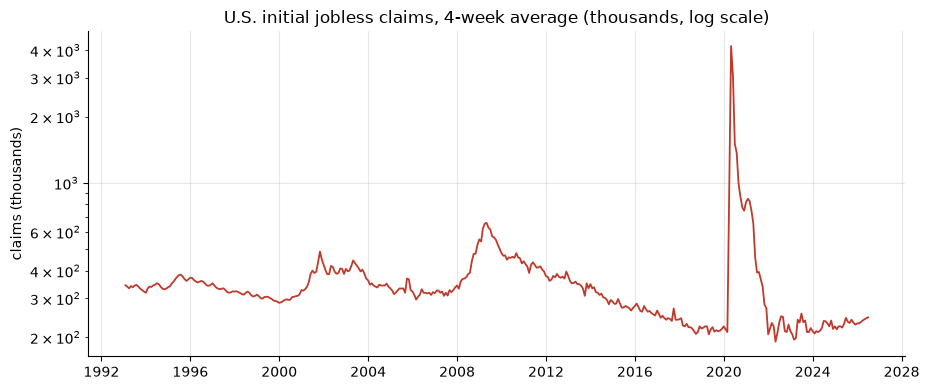

peak 4-wk MA: 4174 thousand, around 2020-04-30


In [2]:
if HAVE_REAL:
    c = F['claims']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(c.index, c.values, c=RED, lw=1.3)
    ax.set_yscale('log')
    ax.set_title('U.S. initial jobless claims, 4-week average (thousands, log scale)')
    ax.set_ylabel('claims (thousands)')
    plt.tight_layout(); plt.show()
    print('peak 4-wk MA:', int(c.max()), 'thousand, around', c.idxmax().date())
else:
    print('no cache — see docs/results.md; COVID 4-wk MA peaked ~4,170k in Apr 2020')

**Now the payoff.** For each horizon, the average forward SPY return in **rising-claims** months next to the return on an **average** month. The folklore predicts the green bars sit *below* the grey ones.

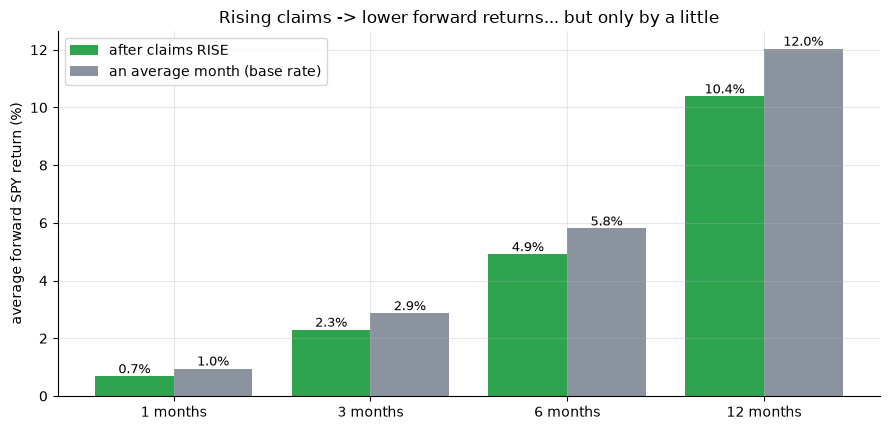

12-month: rising 10.4% vs base 12.0%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    ris = [r['rising_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    ris = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    base = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, ris, .4, color=GREEN, label='after claims RISE')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward SPY return (%)')
ax.set_title('Rising claims -> lower forward returns... but only by a little')
for i,(a,b) in enumerate(zip(ris,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('12-month: rising', f'{ris[-1]:.1f}%', 'vs base', f'{base[-1]:.1f}%')

The direction is right — at 12 months rising-claims returns (**+10.4%**) sit below the base rate (**+12.0%**), and the market is *down* more often (**24%** of the time vs **18%**). But the gap is a couple of points — small enough that, with the numbers we have, it could easily be chance. Hold that thought; the *next* chart is where the story breaks.

**The crucial test: does the claims uptick come *first*?** We slide claims forward and backward against the market and measure how tightly they move together. A real early-warning would show its strongest *downward* link at a **positive lead** (claims lead → bar dips on the right). Watch where it actually dips.

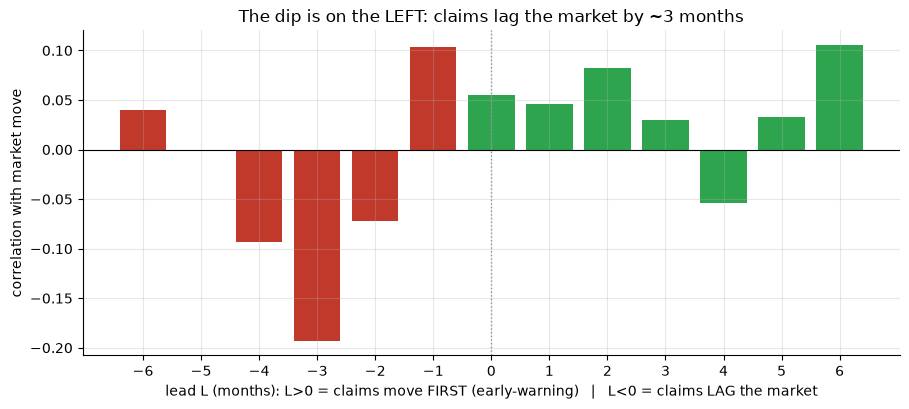

strongest negative link at L=-3 months (claims FOLLOW the market here)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [RED if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = claims move FIRST (early-warning)   |   L<0 = claims LAG the market')
ax.set_ylabel('correlation with market move'); ax.set_xticks(Ls)
ax.set_title('The dip is on the LEFT: claims lag the market by ~3 months')
plt.tight_layout(); plt.show()
imin = int(np.nanargmin(cs))
print(f'strongest negative link at L={Ls[imin]} months (claims FOLLOW the market here)')

There it is. The deepest *negative* bar is at **L = −3** — the claims signal lines up best with a market move that happened **three months earlier**. On the right, where a true early-warning would live (claims moving first), the bars are near zero or even *positive*. **Claims aren't leading the market — they're trailing it.** The recession shows up in stock prices, and only later in the claims average.

**Could you trade it anyway?** Suppose you sold (went to cash) every month claims were rising and held SPY otherwise. Here's that strategy's growth vs just buying and holding.

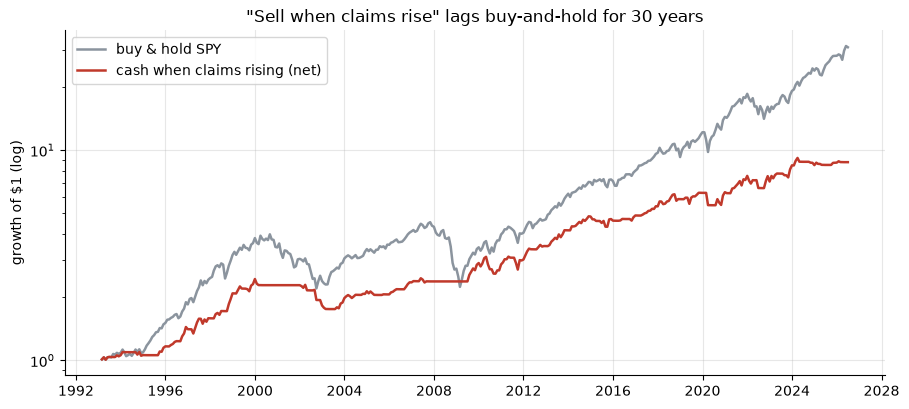

final $1 -> buy&hold 30.9x  vs  overlay 8.8x


In [5]:
if HAVE_REAL:
    rising = st.rising_mask(F); pos = (~rising).astype(float).shift(1)
    rr = F['spy'].pct_change()
    import pandas as pd
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); c=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*c)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold SPY')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='cash when claims rising (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Sell when claims rise" lags buy-and-hold for 30 years')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay {R['overlay'][4]:.1f}%/yr vs buy-hold {R['overlay'][0]:.1f}%/yr (net) — see results.md")

The defensive overlay ends up **well below** buy-and-hold — **+7.0%/yr** vs **+11.4%/yr** net, and a *lower* Sharpe (0.72 vs 0.77). Every time you stepped aside on a claims uptick you mostly missed *gains*, because claims kept rising well into recoveries the market had already started pricing. The signal doesn't just fail to help — **it hurts.**

## 5 · The verdict

- **Signal — Weak.** Rising claims really do precede slightly weaker, more-often-negative returns — but the gap is small, not statistically significant, and fragile to how you define the signal. Real as lore, weak as edge.
- **Tradability — Mirage.** Selling on rising claims **loses to buy-and-hold**. There's nothing to deploy.
- **Early warning? — Not supported.** The claims uptick lines up with a market move that already happened a quarter earlier. Claims **echo** equity weakness; they don't forecast it. The one word that makes the pitch — *early* — is the part the data rejects.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even if the small tilt were real, the operational reality is brutal: claims rise in **roughly half** of all months (every wiggle counts as 'rising'), so a cash-on-rising rule whipsaws you in and out constantly — **109 switches** in 30 years — while the deepest claims surges (the *genuine* recession lows) are exactly the moments you'd most want to be **buying**, not selling. That's why pushing the rule to only fire on a *big* claims jump flips its sign **positive**. There is no version of "sell when claims rise" that both fires early and makes money.

## 7 · Going further 🚪

- **The sibling test.** [Study 268 — Sahm-Rule](../268-sahm-rule/) asks the same question of the famous unemployment-rate recession trigger: real labour signal, but can you trade it?
- **More macro crystal balls.** [Study 266 — Misery-Index](../266-misery-index/) and [Study 267 — M2-Growth](../267-m2-growth/) put other celebrated macro gauges through the same wringer.
- **Build your own.** Swap the 4-week average for the weekly raw series, or pair claims with a *price* trend filter — the lead/lag picture barely budges: a coincident series can't be made to lead by smoothing it differently.

*Think claims lead the market? Show the lead/lag chart dipping on the **right** (positive lead) — then we'll talk.*